<a href="https://colab.research.google.com/github/Lucaschewitch/Algoritmization/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D0%B8_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

Using Colab cache for faster access to the 'car-sales' dataset.
Propuskiiii:
 Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Latest_Launch           0
Power_perf_factor       2
dtype: int64


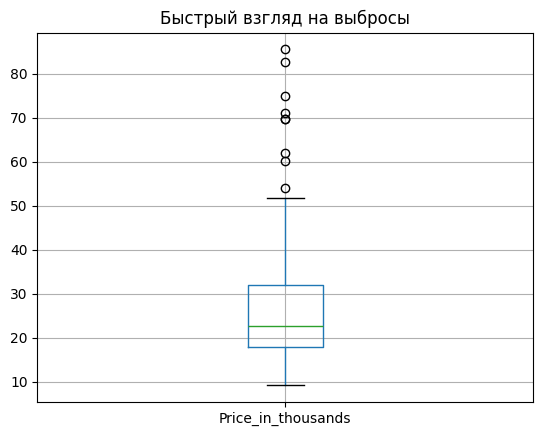

In [2]:
# Ваш код
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

path = kagglehub.dataset_download("gagandeep16/car-sales")
df = pd.read_csv(f"{path}/Car_sales.csv")

print("Propuskiiii:\n", df.isnull().sum())

df.boxplot(column='Price_in_thousands')
plt.title('Быстрый взгляд на выбросы')
plt.show()

- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

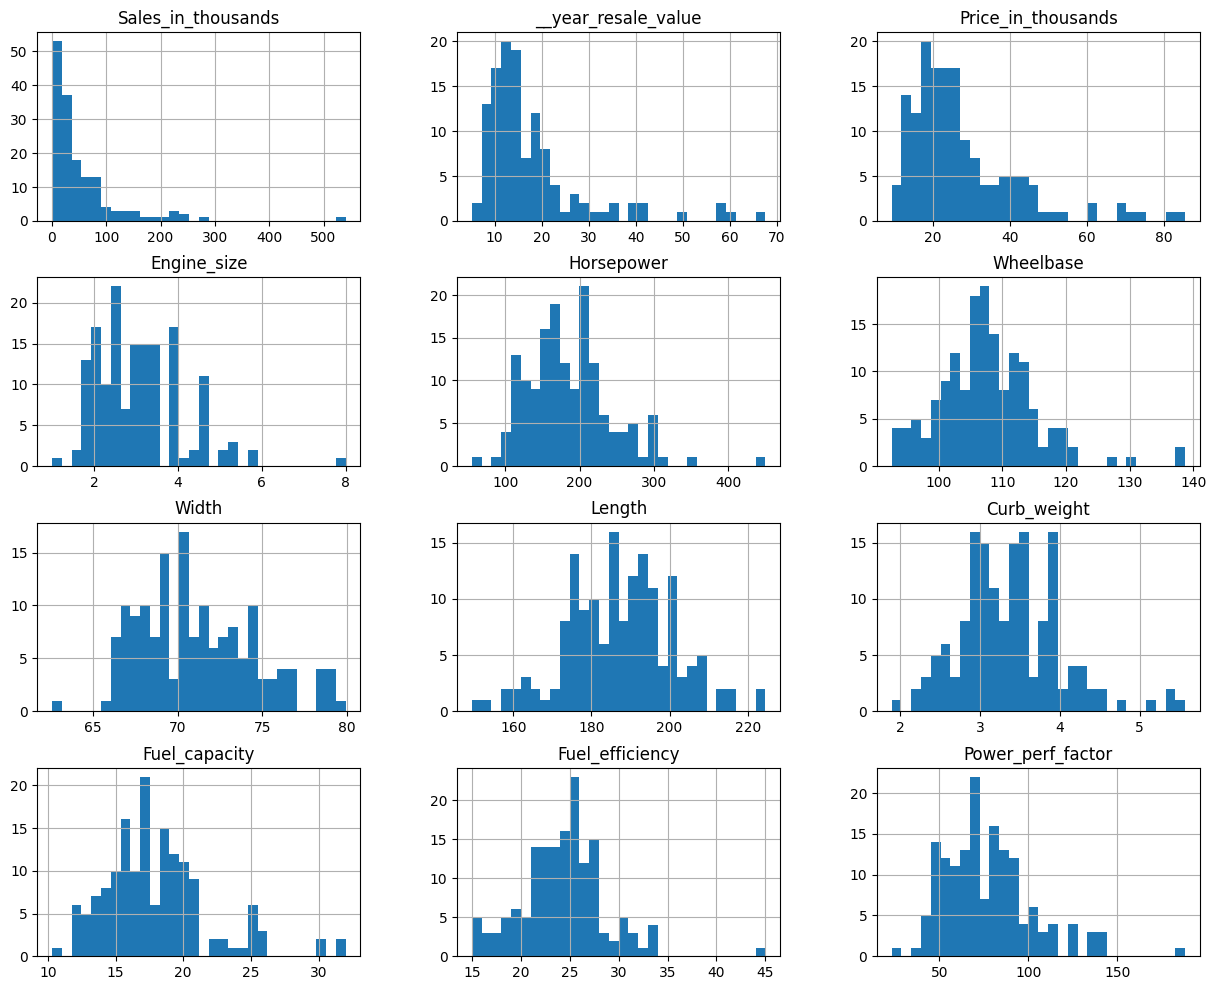

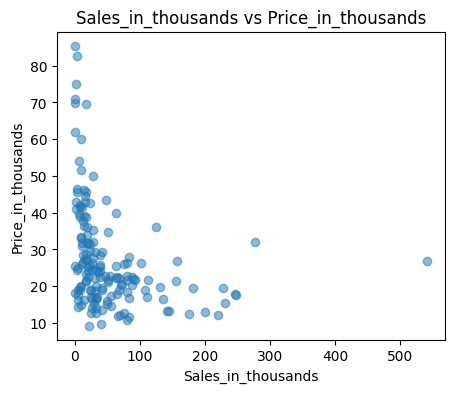

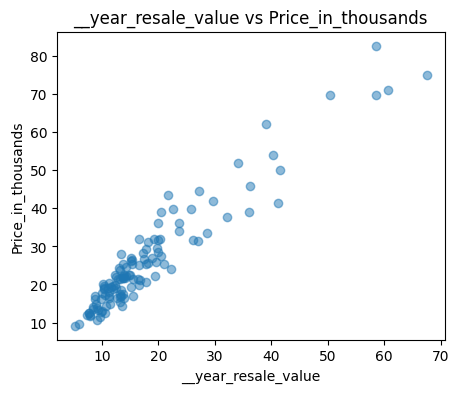

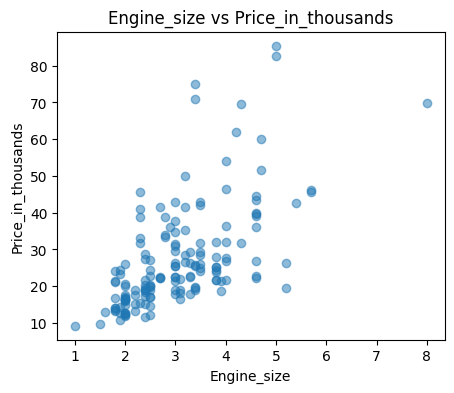

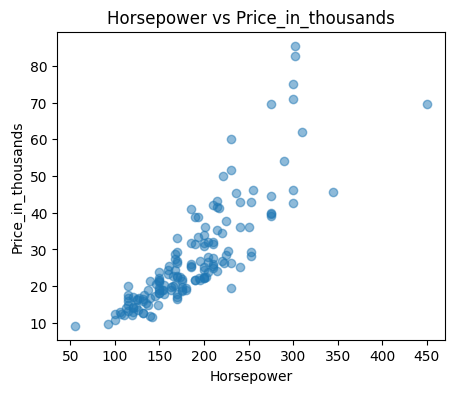

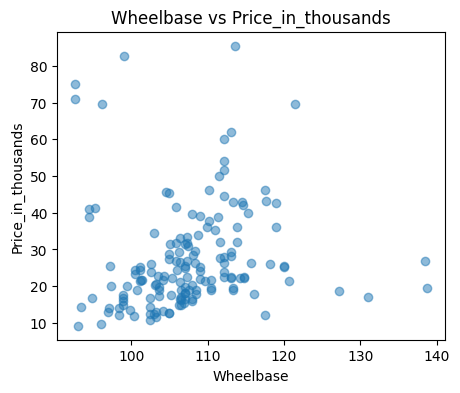

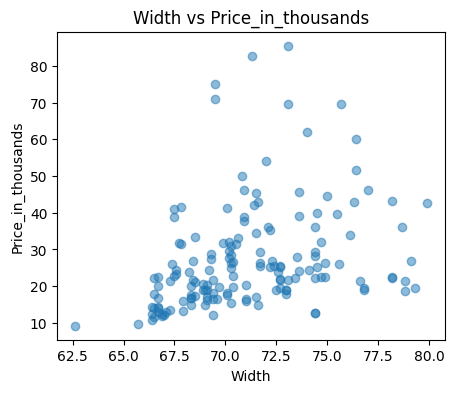

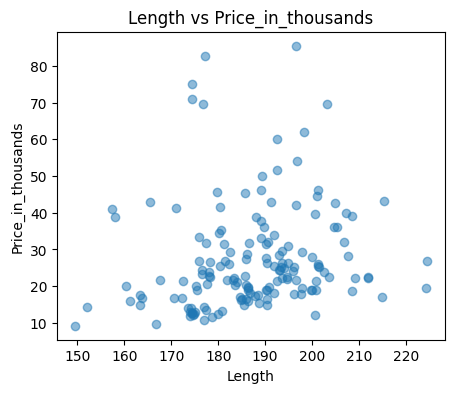

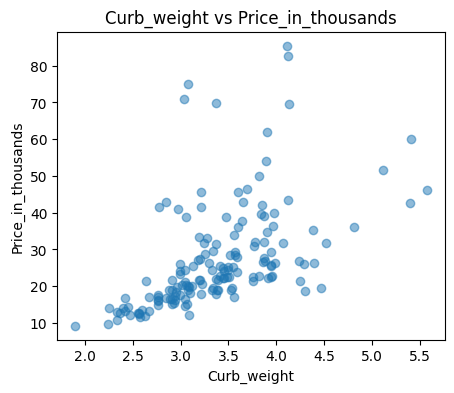

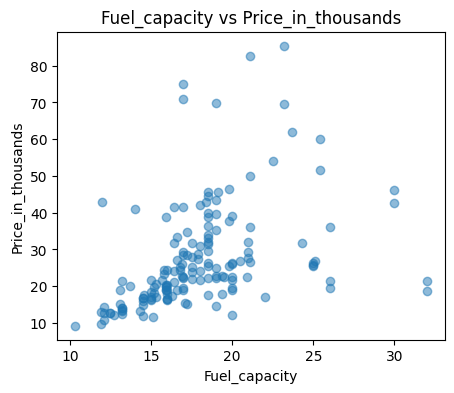

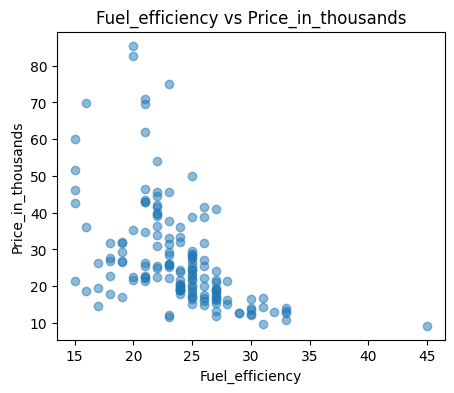

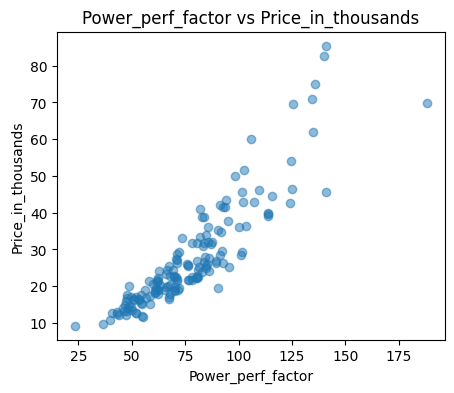

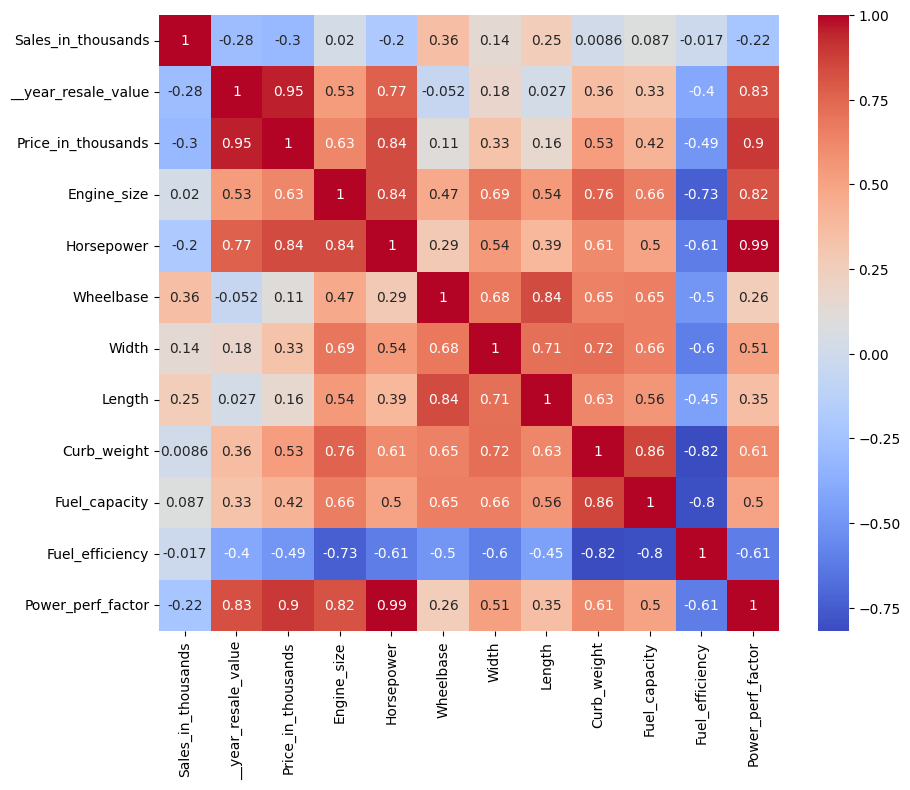

In [4]:
# Ваш код
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].hist(figsize=(15, 12), bins=30)
plt.show()
target = 'Price_in_thousands'
for col in num_cols:
    if col != target:
        plt.figure(figsize=(5,4))
        plt.scatter(df[col], df[target], alpha=0.5)
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f'{col} vs {target}')
        plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [7]:
# Ваш код
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

target = 'Price_in_thousands'
features = ['Manufacturer', 'Model', 'Sales_in_thousands', '__year_resale_value', 'Vehicle_type', 'Price_in_thousands', 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Latest_Launch', 'Power_perf_factor']
X = df[features]
y = df[target]

num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=['object']).columns
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])
X_processed = preprocessor.fit_transform(X)
q99 = y.quantile(0.99)
mask = y <= q99
X_processed = X_processed[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [8]:
# Ваш код
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

models = {}

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
models['Linear'] = lr

ridge = Ridge()
params_ridge = {'alpha': np.logspace(-4, 4, 50)}
grid_ridge = GridSearchCV(ridge, params_ridge, cv=5, scoring='r2', n_jobs=-1)
grid_ridge.fit(X_train_scaled, y_train)
models['Ridge'] = grid_ridge.best_estimator_
print(f"Best alpha for Ridge: {grid_ridge.best_params_['alpha']:.4f}")

lasso = Lasso(max_iter=10000)
params_lasso = {'alpha': np.logspace(-4, 4, 50)}
random_lasso = RandomizedSearchCV(lasso, params_lasso, n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1)
random_lasso.fit(X_train_scaled, y_train)
models['Lasso'] = random_lasso.best_estimator_
print(f"Best alpha for Lasso: {random_lasso.best_params_['alpha']:.4f}")

en = ElasticNet(max_iter=10000)
params_en = {'alpha': np.logspace(-4, 4, 30), 'l1_ratio': np.linspace(0.1, 0.9, 9)}
random_en = RandomizedSearchCV(en, params_en, n_iter=30, cv=5, scoring='r2', random_state=42, n_jobs=-1)
random_en.fit(X_train_scaled, y_train)
models['ElasticNet'] = random_en.best_estimator_
print(f"Best ElasticNet: alpha={random_en.best_params_['alpha']:.4f}, l1_ratio={random_en.best_params_['l1_ratio']:.2f}")

Best alpha for Ridge: 0.0001
Best alpha for Lasso: 0.0020
Best ElasticNet: alpha=0.2043, l1_ratio=0.90


- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [9]:
# Ваш код
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

metrics_dict = {}
for name, model in models.items():
    pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    metrics_dict[name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"\n{name}:")
    print(f"  MSE  = {mse:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  MAE  = {mae:.4f}")
    print(f"  R2   = {r2:.4f}")


Linear:
  MSE  = 15.8587
  RMSE = 3.9823
  MAE  = 3.0529
  R2   = 0.8138

Ridge:
  MSE  = 15.8587
  RMSE = 3.9823
  MAE  = 3.0529
  R2   = 0.8138

Lasso:
  MSE  = 0.0000
  RMSE = 0.0024
  MAE  = 0.0019
  R2   = 1.0000

ElasticNet:
  MSE  = 0.4905
  RMSE = 0.7004
  MAE  = 0.5151
  R2   = 0.9942


- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



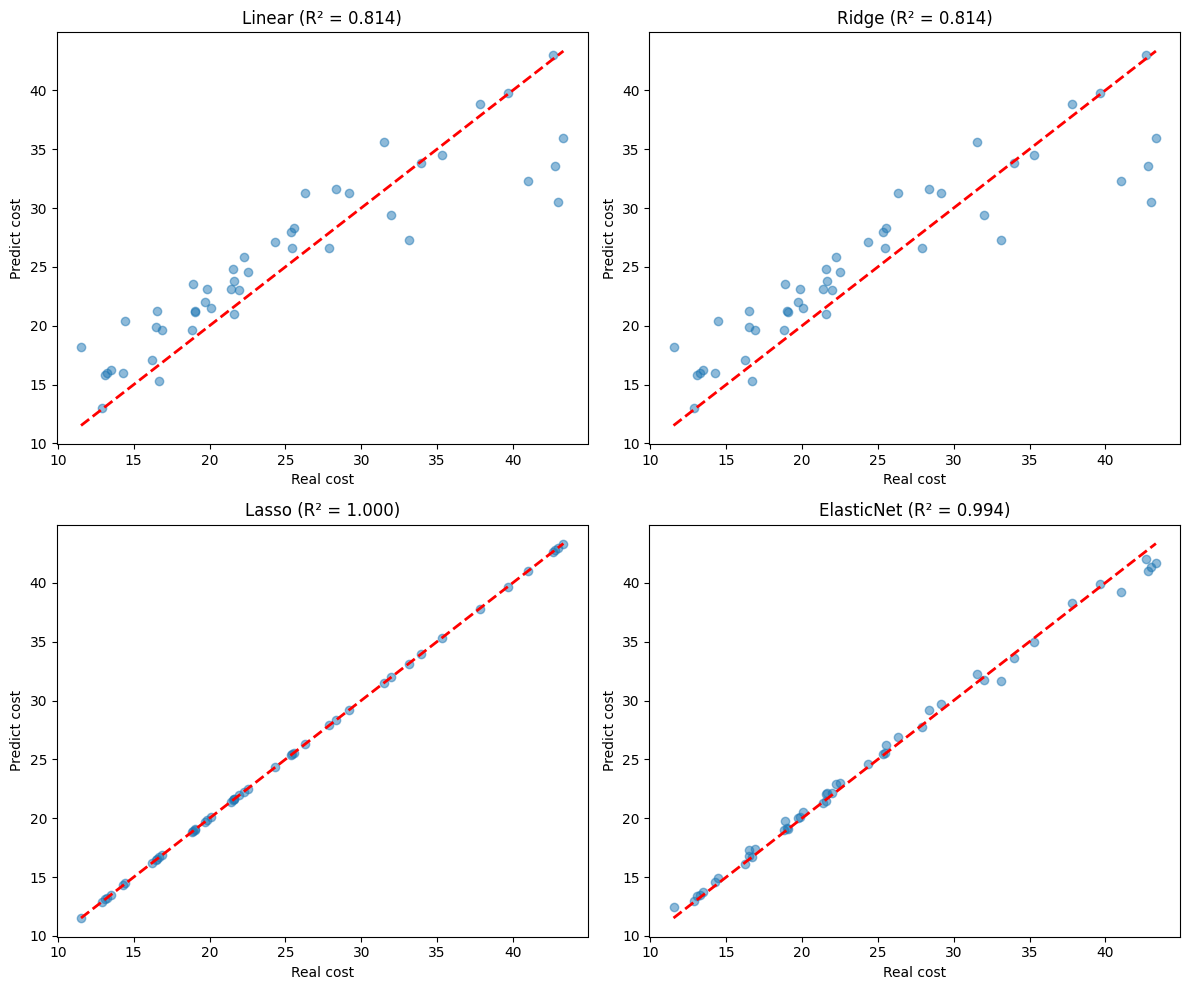

In [11]:
# Ваш код
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (name, model) in enumerate(models.items()):
    pred = model.predict(X_test_scaled)
    ax = axes[i]
    ax.scatter(y_test, pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Real cost')
    ax.set_ylabel('Predict cost')
    ax.set_title(f'{name} (R² = {metrics_dict[name]["R2"]:.3f})')
plt.tight_layout()
plt.show()



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [34]:
# Ваш код
results = pd.DataFrame(metrics_dict).T
print("\nMetric table")
print(results.round(4))

best_model = results['R2'].idxmax()
print(f"\nBest model: {best_model}")
print("Metrics:")
print(results.loc[best_model])

if best_model == 'Ridge':
    print(f"Optimum alpha: {grid_ridge.best_params_['alpha']:.4f}")
elif best_model == 'Lasso':
    print(f"Optimum alpha: {random_lasso.best_params_['alpha']:.4f}")
elif best_model == 'ElasticNet':
    print(f"Optimum: alpha={random_en.best_params_['alpha']:.4f}, l1_ratio={random_en.best_params_['l1_ratio']:.2f}")


Metric table
                MSE    RMSE     MAE      R2
Linear      15.8587  3.9823  3.0529  0.8138
Ridge       15.8587  3.9823  3.0529  0.8138
Lasso        0.0000  0.0024  0.0019  1.0000
ElasticNet   0.4905  0.7004  0.5151  0.9942

Best model: Lasso
Metrics:
MSE     0.000006
RMSE    0.002400
MAE     0.001891
R2      1.000000
Name: Lasso, dtype: float64
Optimum alpha: 0.0020


---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


   Year Country         Region  Crop_Type  Average_Temperature_C  \
0  2001   India    West Bengal       Corn                   1.55   
1  2024   China          North       Corn                   3.23   
2  2001  France  Ile-de-France      Wheat                  21.11   
3  2001  Canada       Prairies     Coffee                  27.85   
4  1998   India     Tamil Nadu  Sugarcane                   2.19   

   Total_Precipitation_mm  CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
0                  447.06             15.22                 1.737   
1                 2913.57             29.82                 1.737   
2                 1301.74             25.75                 1.719   
3                 1154.36             13.91                 3.890   
4                 1627.48             11.81                 1.080   

   Extreme_Weather_Events  Irrigation_Access_%  Pesticide_Use_KG_per_HA  \
0                       8                14.54                    10.08   
1                       8 

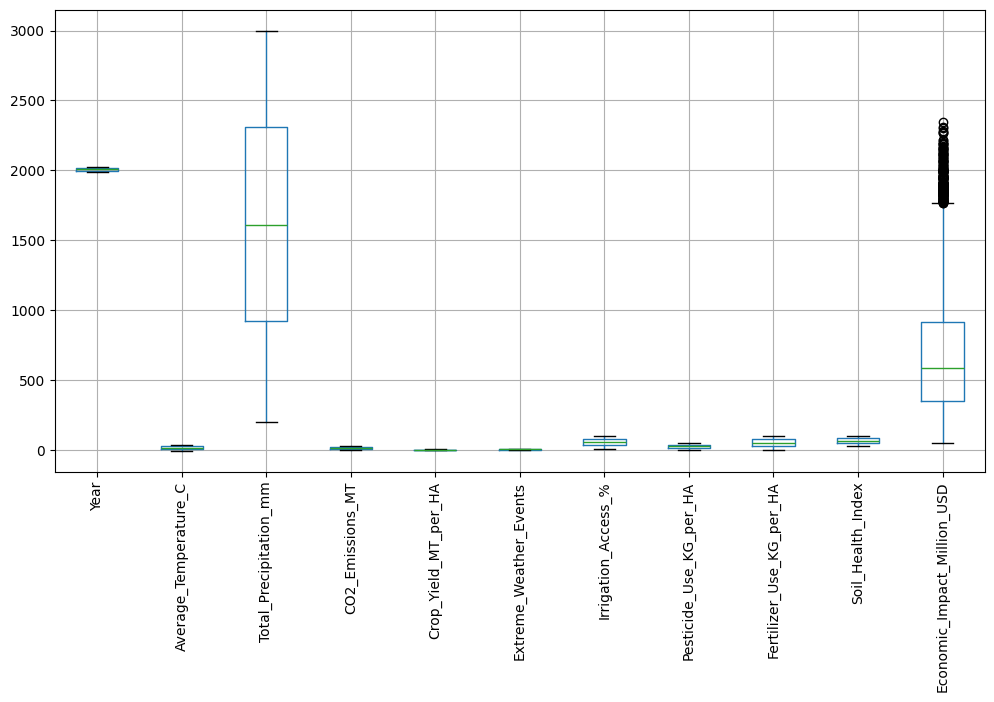

In [24]:
# Ваш код
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/sample_data/climate_change_impact_on_agriculture_2024.csv'
df = pd.read_csv(file_path)

print(df.head())
print(df.info())
print("\nPropuskiii:\n", df.isnull().sum())

df.boxplot(figsize=(12, 6), rot=90)
plt.show()




- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.




Target col: Crop_Yield_MT_per_HA
Num cols: ['Year', 'Average_Temperature_C', 'Total_Precipitation_mm', 'CO2_Emissions_MT', 'Extreme_Weather_Events', 'Irrigation_Access_%', 'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index', 'Economic_Impact_Million_USD']


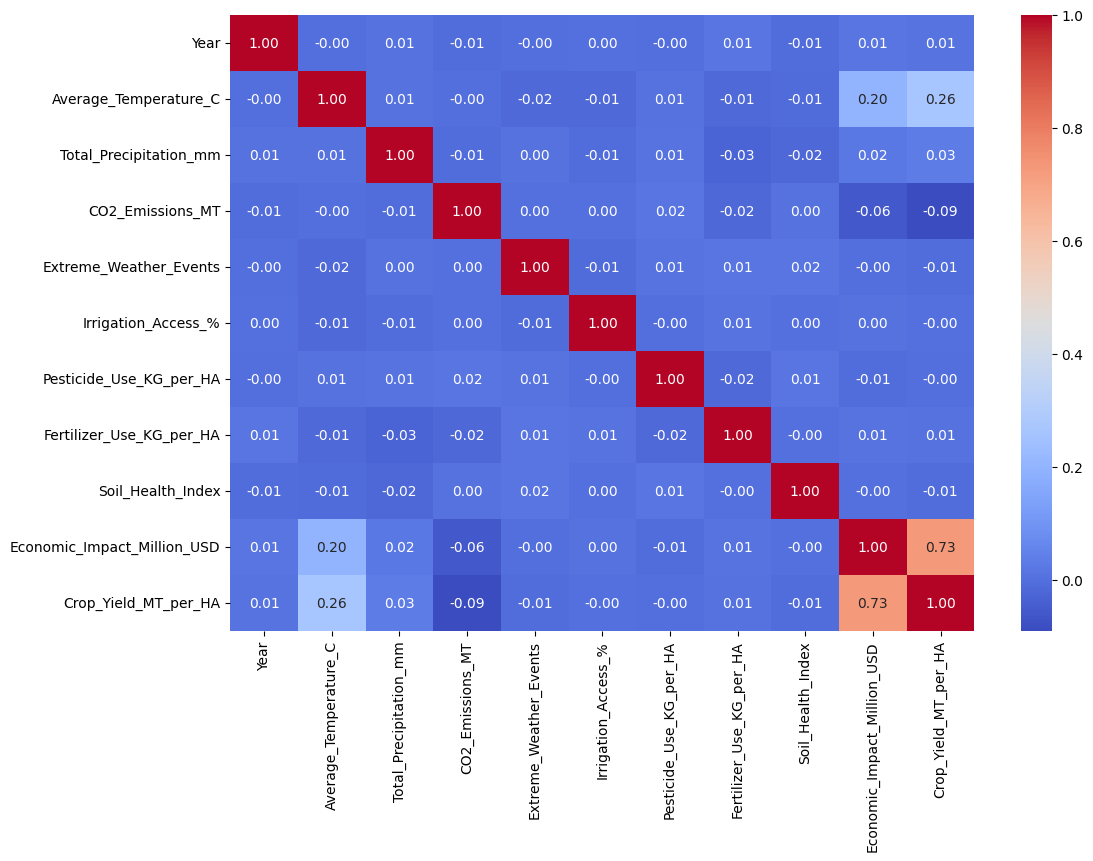

Признаки по корреляции с Crop_Yield_MT_per_HA:
Economic_Impact_Million_USD    0.726358
Average_Temperature_C          0.263781
CO2_Emissions_MT               0.089868
Total_Precipitation_mm         0.029728
Year                           0.010734
Name: Crop_Yield_MT_per_HA, dtype: float64


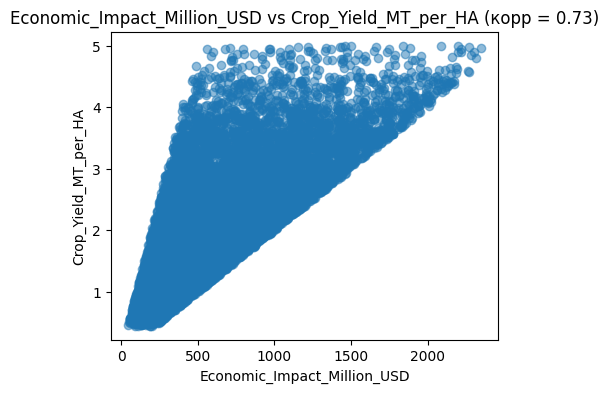

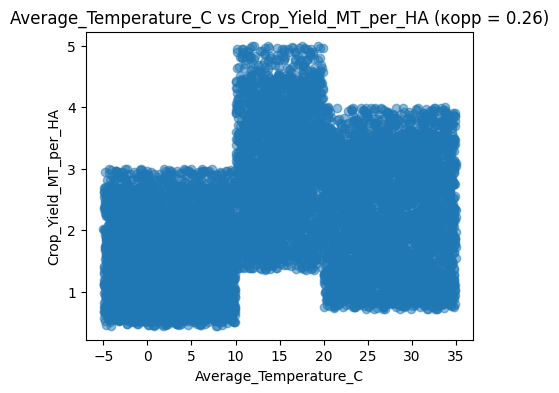

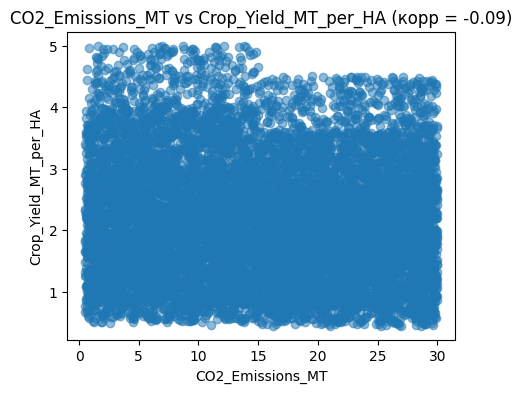

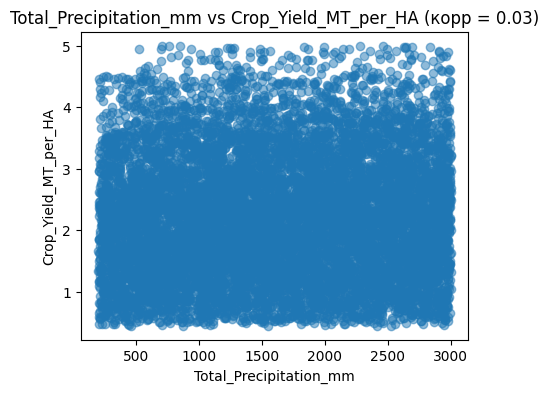

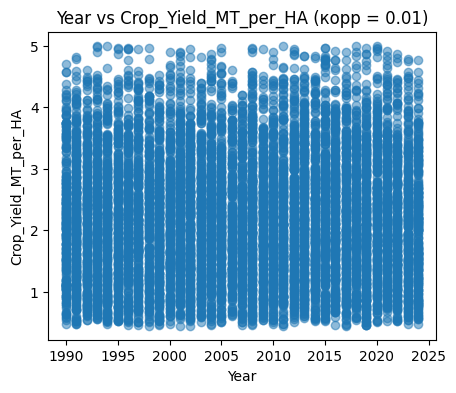

In [27]:
# Ваш код
target_col = None
for col in df.columns:
    if 'yield' in col.lower() or 'урожай' in col.lower() or 'production' in col.lower():
        target_col = col
        break

print(f"\nTarget col: {target_col}")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)
else:
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols.remove(target_col)

print("Num cols:", num_cols)

plt.figure(figsize=(12, 8))
corr = df[num_cols + [target_col]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

corr_target = abs(corr[target_col].drop(target_col)).sort_values(ascending=False)
top_features = corr_target.head(5).index
print(f"Признаки по корреляции с {target_col}:\n{corr_target.head(5)}")

for feat in top_features:
    plt.figure(figsize=(5,4))
    plt.scatter(df[feat], df[target_col], alpha=0.5)
    plt.xlabel(feat)
    plt.ylabel(target_col)
    plt.title(f'{feat} vs {target_col} (корр = {corr.loc[feat, target_col]:.2f})')
    plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [28]:
# Ваш код
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = df[num_cols].copy()
y = df[target_col].copy()

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

q99 = y.quantile(0.99)
q1 = y.quantile(0.01)
mask = (y <= q99) & (y >= q1)
X_clean = X_imputed[mask]
y_clean = y[mask]

print(f"Clean: {len(y) - len(y_clean)}")

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"train {X_train_scaled.shape}, test {X_test_scaled.shape}")

Clean: 195
train (6863, 10), test (2942, 10)




- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [29]:
# Ваш код
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

models = {}

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
models['Linear'] = lr

ridge = Ridge()
params_ridge = {'alpha': np.logspace(-4, 4, 50)}
random_ridge = RandomizedSearchCV(ridge, params_ridge, n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1)
random_ridge.fit(X_train_scaled, y_train)
models['Ridge'] = random_ridge.best_estimator_
print(f"Best alpha for Ridge: {random_ridge.best_params_['alpha']:.4f}")

lasso = Lasso(max_iter=10000)
params_lasso = {'alpha': np.logspace(-4, 4, 50)}
grid_lasso = GridSearchCV(lasso, params_lasso, cv=5, scoring='r2', n_jobs=-1)
grid_lasso.fit(X_train_scaled, y_train)
models['Lasso'] = grid_lasso.best_estimator_
print(f"Best alpha for Lasso: {grid_lasso.best_params_['alpha']:.4f}")

en = ElasticNet(max_iter=10000)
params_en = {'alpha': np.logspace(-4, 4, 30), 'l1_ratio': np.linspace(0.1, 0.9, 9)}
random_en = RandomizedSearchCV(en, params_en, n_iter=30, cv=5, scoring='r2', random_state=42, n_jobs=-1)
random_en.fit(X_train_scaled, y_train)
models['ElasticNet'] = random_en.best_estimator_
print(f"Best  ElasticNet: alpha={random_en.best_params_['alpha']:.4f}, l1_ratio={random_en.best_params_['l1_ratio']:.2f}")

Best alpha for Ridge: 7.9060
Best alpha for Lasso: 0.0091
Best  ElasticNet: alpha=0.0045, l1_ratio=0.70


- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [30]:
# Ваш код
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

metrics = {}
for name, model in models.items():
    pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    metrics[name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"\n{name}:")
    print(f"  MSE  = {mse:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  MAE  = {mae:.4f}")
    print(f"  R2   = {r2:.4f}")


Linear:
  MSE  = 0.4294
  RMSE = 0.6553
  MAE  = 0.5267
  R2   = 0.5270

Ridge:
  MSE  = 0.4294
  RMSE = 0.6553
  MAE  = 0.5267
  R2   = 0.5270

Lasso:
  MSE  = 0.4290
  RMSE = 0.6550
  MAE  = 0.5262
  R2   = 0.5275

ElasticNet:
  MSE  = 0.4291
  RMSE = 0.6550
  MAE  = 0.5264
  R2   = 0.5274




- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

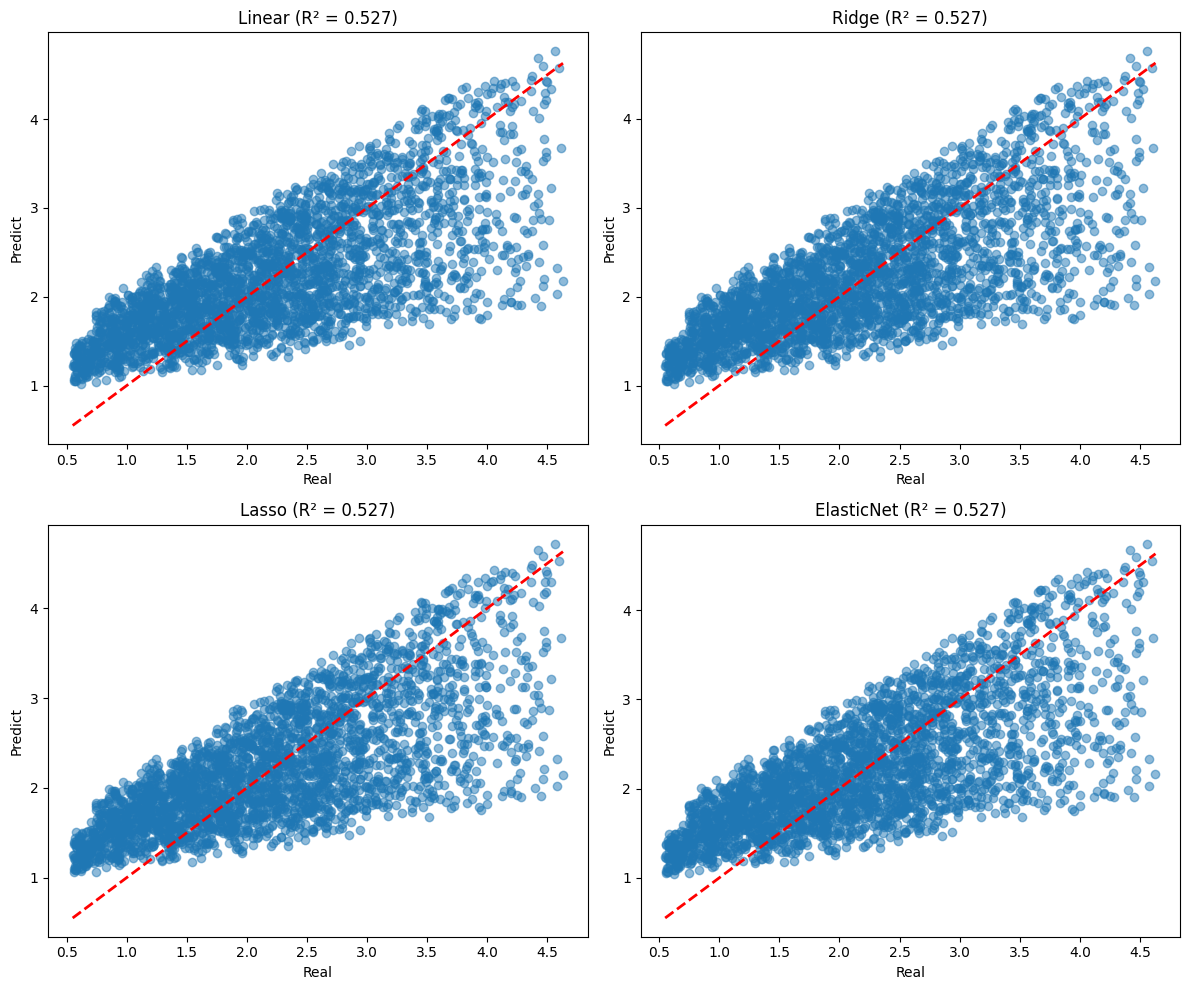

In [32]:
# Ваш код
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (name, model) in enumerate(models.items()):
    pred = model.predict(X_test_scaled)
    ax = axes[i]
    ax.scatter(y_test, pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Real')
    ax.set_ylabel('Predict')
    ax.set_title(f'{name} (R² = {metrics[name]["R2"]:.3f})')
plt.tight_layout()
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [35]:
# Ваш код
results = pd.DataFrame(metrics).T
print("\nMetric table")
print(results.round(4))

best_model_name = results['R2'].idxmax()
best_model = models[best_model_name]
print(f"\nBest: {best_model_name}")
print("Metrics:")
print(results.loc[best_model_name])

# Гиперпараметры лучшей модели
if best_model_name == 'Ridge':
    print(f"Optimum alpha: {random_ridge.best_params_['alpha']:.4f}")
elif best_model_name == 'Lasso':
    print(f"Optimum alpha: {grid_lasso.best_params_['alpha']:.4f}")
elif best_model_name == 'ElasticNet':
    print(f"Optimum параметры: alpha={random_en.best_params_['alpha']:.4f}, l1_ratio={random_en.best_params_['l1_ratio']:.2f}")


Metric table
               MSE    RMSE     MAE      R2
Linear      0.4294  0.6553  0.5267  0.5270
Ridge       0.4294  0.6553  0.5267  0.5270
Lasso       0.4290  0.6550  0.5262  0.5275
ElasticNet  0.4291  0.6550  0.5264  0.5274

Best: Lasso
Metrics:
MSE     0.428989
RMSE    0.654973
MAE     0.526160
R2      0.527470
Name: Lasso, dtype: float64
Optimum alpha: 0.0091


- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.




Coefs
                       Feat      Coef
Economic_Impact_Million_USD  0.657465
      Average_Temperature_C  0.118522
           CO2_Emissions_MT -0.019070
     Total_Precipitation_mm  0.004181
        Irrigation_Access_% -0.001202
                       Year  0.000000
     Extreme_Weather_Events -0.000000
    Pesticide_Use_KG_per_HA  0.000000
   Fertilizer_Use_KG_per_HA  0.000000
          Soil_Health_Index -0.000000


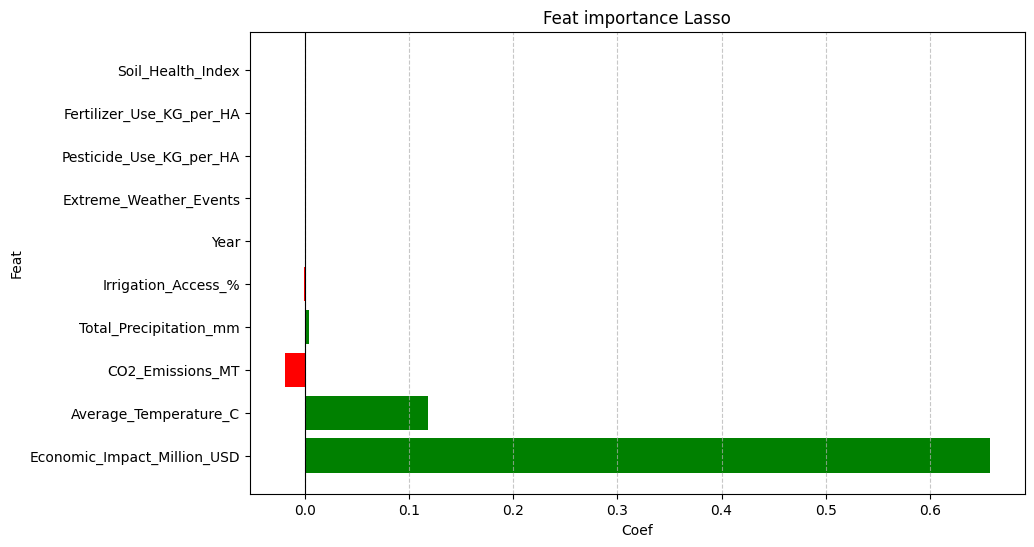


Delete by Lasso:
['Year', 'Extreme_Weather_Events', 'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index']


In [39]:
# Ваш код
# Извлекаем коэффициенты
coef = best_model.coef_
feature_names = num_cols

# Создаём DataFrame с важностью
importance = pd.DataFrame({'Feat': feature_names, 'Coef': coef})
importance = importance.sort_values('Coef', key=abs, ascending=False)

print("\nCoefs")
print(importance.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'green' for c in importance['Coef']]
plt.barh(importance['Feat'], importance['Coef'], color=colors)
plt.xlabel('Coef')
plt.ylabel('Feat')
plt.title(f'Feat importance {best_model_name}')
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

if best_model_name == 'Lasso':
    zero_coef = importance[abs(importance['Coef']) < 1e-6]
    if len(zero_coef) > 0:
        print("\nDelete by Lasso:")
        print(zero_coef['Feat'].tolist())

#### **Интерпретация результатов (пример формулировки для отчёта):**


**[ТРЕБУЕТСЯ ЗАПОЛНИТЬ!]**


> На основе анализа коэффициентов лучшей модели установлено, что:
> - **Положительное влияние** на урожайность оказывают: Economic_Impact_Million_USD,Average_Temperature_C, Total_Precipitation_mm.
> - **Отрицательное влияние** на урожайность оказывают: CO2_Emissions_MT,Irrigation_Access_%.
> - Наиболее значимым фактором является Economic_Impact_Million_USD с коэффициентом  0.657, что означает: при увеличении данного показателя на 1 единицу (при прочих равных) урожайность изменяется на 0.657 единиц.

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [40]:
# Ваш код
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/sample_data/bank-additional-full.csv', sep=';')
print(df.head())
print(df.info())
print(df.isnull().sum())

print(df['y'].value_counts())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [41]:
# Ваш код
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop('y', axis=1)
y = (df['y'] == 'yes').astype(int)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(num_cols)
print(cat_cols)

preprocessor = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)])
X_processed = preprocessor.fit_transform(X)
print(X_processed.shape)

['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
(41188, 63)


- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [42]:
# Ваш код
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Class in train: {y_train.mean():.3f}, in test: {y_test.mean():.3f}")

Train: (28831, 63), Test: (12357, 63)
Class in train: 0.113, in test: 0.113


- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [44]:
# Ваш код
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

models = {}
best_estimators = {}

lr_l2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
params_l2 = {'C': np.logspace(-2, 2, 10)}
grid_l2 = GridSearchCV(lr_l2, params_l2, cv=3, scoring='f1', n_jobs=-1)
grid_l2.fit(X_train, y_train)
models['L2'] = grid_l2.best_estimator_
best_estimators['L2'] = grid_l2.best_params_
print(f"L2: best C = {grid_l2.best_params_['C']:.4f}, f1 (cv) = {grid_l2.best_score_:.4f}")

lr_l1 = LogisticRegression(penalty='l1', solver='saga', max_iter=1000)
params_l1 = {'C': np.logspace(-2, 2, 10)}
random_l1 = RandomizedSearchCV(lr_l1, params_l1, n_iter=5, cv=3, scoring='f1', random_state=42, n_jobs=1)
random_l1.fit(X_train, y_train)
models['L1'] = random_l1.best_estimator_
best_estimators['L1'] = random_l1.best_params_
print(f"L1: best C = {random_l1.best_params_['C']:.4f}, f1 (cv) = {random_l1.best_score_:.4f}")

lr_en = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=1000)
params_en = {'C': np.logspace(-2, 2, 5), 'l1_ratio': [0.3, 0.5, 0.7]}
random_en = RandomizedSearchCV(lr_en, params_en, n_iter=6, cv=3, scoring='f1', random_state=42, n_jobs=1)
random_en.fit(X_train, y_train)
models['ElasticNet'] = random_en.best_estimator_
best_estimators['ElasticNet'] = random_en.best_params_
print(f"ElasticNet: best C = {random_en.best_params_['C']:.4f}, l1_ratio = {random_en.best_params_['l1_ratio']:.2f}, f1 (cv) = {random_en.best_score_:.4f}")

L2: best C = 100.0000, f1 (cv) = 0.5163
L1: best C = 1.6681, f1 (cv) = 0.5175
ElasticNet: best C = 1.0000, l1_ratio = 0.70, f1 (cv) = 0.5187



- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.


L2:
  Accuracy  = 0.9120
  Precision = 0.6735
  Recall    = 0.4239
  F1        = 0.5203


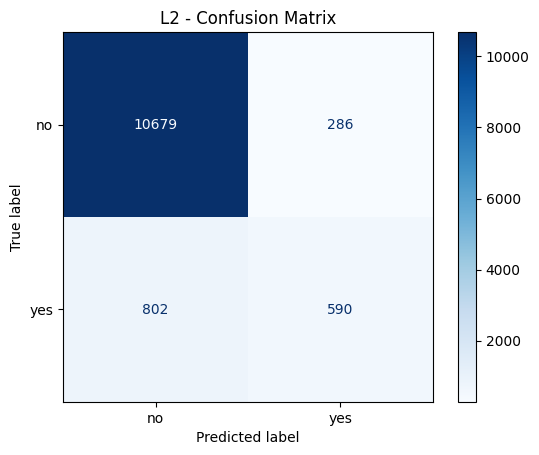


L1:
  Accuracy  = 0.9121
  Precision = 0.6739
  Recall    = 0.4260
  F1        = 0.5220


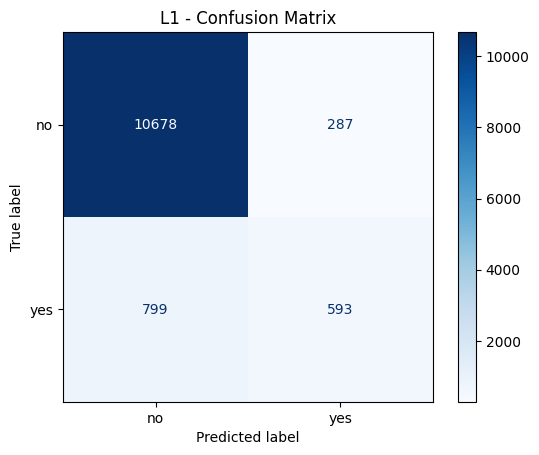


ElasticNet:
  Accuracy  = 0.9120
  Precision = 0.6727
  Recall    = 0.4253
  F1        = 0.5211


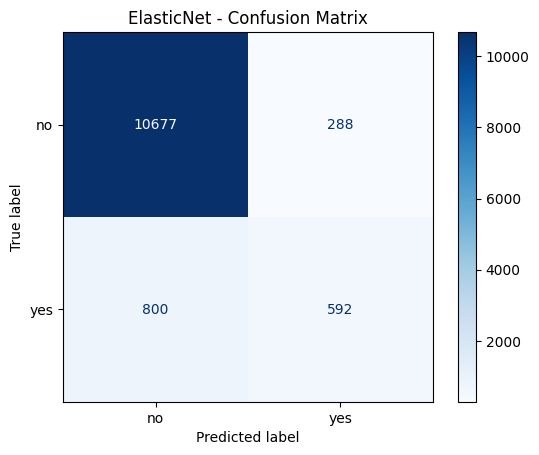

In [45]:
# Ваш код
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

metrics_dict = {}
for name, model in models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    metrics_dict[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f"\n{name}:")
    print(f"  Accuracy  = {acc:.4f}")
    print(f"  Precision = {prec:.4f}")
    print(f"  Recall    = {rec:.4f}")
    print(f"  F1        = {f1:.4f}")

    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



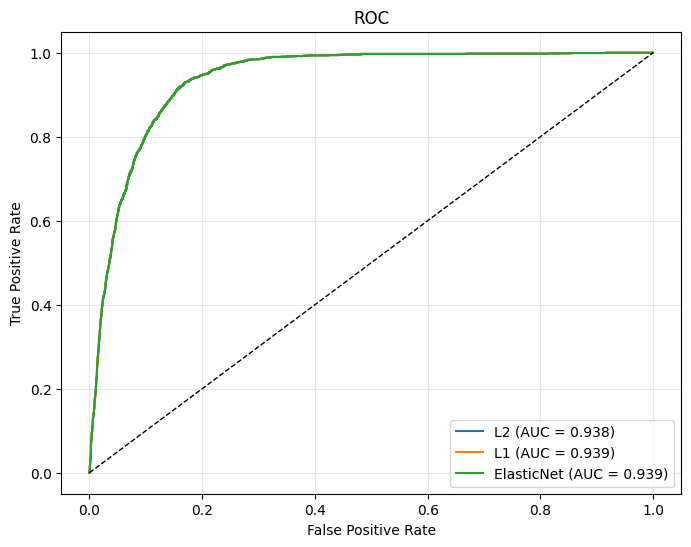

In [46]:
# Ваш код
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))
for name, model in models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.


Metric table
            Accuracy  Precision  Recall      F1
L2            0.9120     0.6735  0.4239  0.5203
L1            0.9121     0.6739  0.4260  0.5220
ElasticNet    0.9120     0.6727  0.4253  0.5211

Best: L1
Metrics:
Accuracy     0.912115
Precision    0.673864
Recall       0.426006
F1           0.522007
Name: L1, dtype: float64
Optimum: {'C': np.float64(1.6681005372000592)}
AUC best: 0.9385


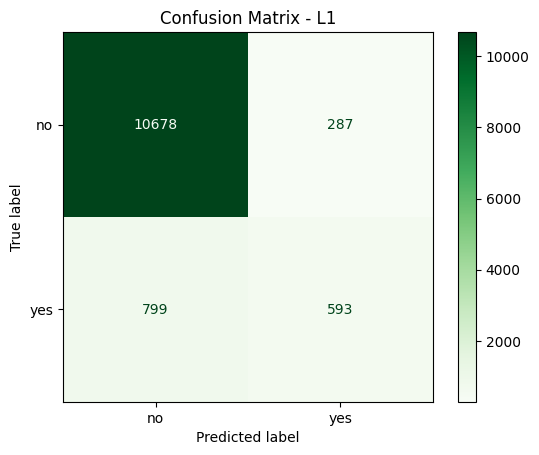

In [47]:
# Ваш код
# Сводная таблица
results = pd.DataFrame(metrics_dict).T
print("\nMetric table")
print(results.round(4))

best_model_name = results['F1'].idxmax()
best_model = models[best_model_name]
print(f"\nBest: {best_model_name}")
print("Metrics:")
print(results.loc[best_model_name])
print("Optimum:", best_estimators[best_model_name])

from sklearn.metrics import roc_auc_score
y_pred_proba = best_model.predict_proba(X_test)[:,1]
best_auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC best: {best_auc:.4f}")

cm_best = confusion_matrix(y_test, best_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['no', 'yes'])
disp.plot(cmap='Greens')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()